np.float64(1.5160100174873994)

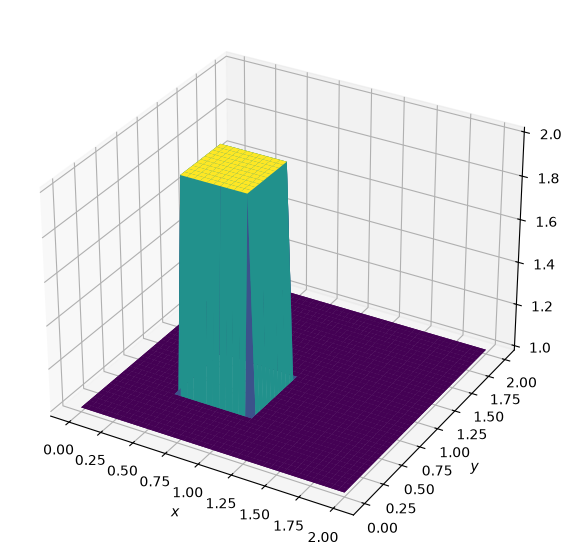

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import clear_output

nx = 41
ny = 41
nt = 120

dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
sigma = 0.009
nu = 0.01
dt = sigma * dx

x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)

u = np.ones((ny, nx))
v = np.ones((ny, nx))

u[int(.5 / dy):int(1 / dy + 1),int(.5 / dx):int(1 / dx + 1)] = 2 
v[int(.5 / dy):int(1 / dy + 1),int(.5 / dx):int(1 / dx + 1)] = 2

fig = plt.figure(figsize=(11, 7), dpi=100)
ax = fig.add_subplot(projection='3d')
X, Y = np.meshgrid(x, y)
ax.plot_surface(X, Y, u, cmap=cm.viridis, rstride=1, cstride=1)
ax.plot_surface(X, Y, v, cmap=cm.viridis, rstride=1, cstride=1)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

np.mean(np.sqrt(u**2 + v**2))

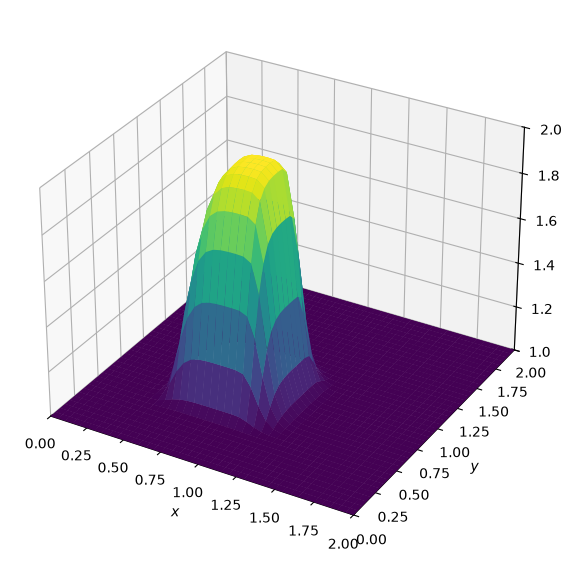

np.float64(1.5088843410696815)

In [2]:
for n in range(nt):
    un = u.copy()
    vn = v.copy()

    u[1:-1, 1:-1] = (un[1:-1, 1:-1]
                    - dt / dx * un[1:-1, 1:-1] * (un[1:-1, 1:-1] - un[1:-1, 0:-2])
                    - dt / dy * vn[1:-1, 1:-1] * (un[1:-1, 1:-1] - un[0:-2, 1:-1])
                    + nu * dt / dx**2 * (un[1:-1,2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2])
                    + nu * dt / dy**2 * (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1]))
    
    v[1:-1, 1:-1] = (vn[1:-1, 1:-1]
                    - dt / dx * un[1:-1, 1:-1] * (vn[1:-1, 1:-1] - vn[1:-1, 0:-2])
                    - dt / dy * vn[1:-1, 1:-1] * (vn[1:-1, 1:-1] - vn[0:-2, 1:-1])
                    + nu * dt / dx**2 * (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, 0:-2])
                    + nu * dt / dy**2 * (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[0:-2, 1:-1]))
        
    u[0, :] = 1
    u[-1, :] = 1
    u[:, 0] = 1
    u[:, -1] = 1
    
    v[0, :] = 1
    v[-1, :] = 1
    v[:, 0] = 1
    v[:, -1] = 1
    clear_output(True)
    
    fig = plt.figure(figsize=(11, 7), dpi=100)
    ax = fig.add_subplot(projection='3d')
    X, Y = np.meshgrid(x, y)
    ax.plot_surface(X, Y, u, cmap=cm.viridis, rstride=1, cstride=1)
    ax.plot_surface(X, Y, v, cmap=cm.viridis, rstride=1, cstride=1)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.axis([0, 2, 0, 2, 1, 2])

    plt.pause(0.0001)

np.mean(np.sqrt(u**2 + v**2))